# Training an MLP Model for Classification

The MFCC features are used for training of an MLP model and we evaluate its performance using standard metrics.

In [8]:
!pip install torchsummary

We begin by loading the necessary packages and setting all necessary parameter variables.

In [9]:
import os
import numpy as np
import helperFncs as hf
import models as md
import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

FOLDER_TRAIN = '/home/jovyan/Data/Post_MFCC/Train/'
FOLDER_VAL = '/home/jovyan/Data/Post_MFCC/Val/'

Next, we load all the traing and validation data.

In [10]:
def loadData(folderIn):
    fileList = sorted([f for f in os.listdir(folderIn) if f.endswith('.h5')])

    mfcc = np.array([])
    labels = np.array([])
    for fileName in fileList:
        file_path = os.path.join(folderIn, fileName)
        data = hf.h5_to_dict(file_path)
        mfcc = np.concatenate((mfcc, data['mfcc']), axis=0) if mfcc.size else data['mfcc']
        labels = np.concatenate((labels, data['labels']), axis=0) if labels.size else data['labels']

    return mfcc, labels

train_mfcc, train_labels = loadData(FOLDER_TRAIN)
print(f"Size of training set: {len(train_mfcc)}")
val_mfcc, val_labels = loadData(FOLDER_VAL)
print(f"Size of validation set: {len(val_mfcc)}")

Size of training set: 35151
Size of validation set: 8746


Let's specify the model and use the GPU if available.

In [11]:
import importlib
importlib.reload(md)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Get input and output dimensions
input_dim = train_mfcc.shape[1]  # 32 MFCC features
output_dim = len(np.unique(train_labels))  # Number of unique classes

# Instantiate model and move to device
model = md.MLP_Baseline(input_dim, output_dim).to(device)

# Plot model summary
summary(model, input_size=(input_dim,))

Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]           2,112
              ReLU-2                   [-1, 64]               0
            Linear-3                    [-1, 4]             260
Total params: 2,372
Trainable params: 2,372
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


Training the model while maintaining the best performing model.

... Model Saved
... Model Saved
... Model Saved
Epoch [10/100] - Training Loss: 0.4228, Validation Accuracy: 0.8550
... Model Saved
... Model Saved
... Model Saved
Epoch [20/100] - Training Loss: 0.3842, Validation Accuracy: 0.8524
Epoch [30/100] - Training Loss: 0.3648, Validation Accuracy: 0.8348
Epoch [40/100] - Training Loss: 0.3521, Validation Accuracy: 0.8427
... Model Saved
Epoch [50/100] - Training Loss: 0.3394, Validation Accuracy: 0.8540
Epoch [60/100] - Training Loss: 0.3369, Validation Accuracy: 0.8518
Epoch [70/100] - Training Loss: 0.3289, Validation Accuracy: 0.8581
Epoch [80/100] - Training Loss: 0.3214, Validation Accuracy: 0.8531
Epoch [90/100] - Training Loss: 0.3197, Validation Accuracy: 0.8478
Epoch [100/100] - Training Loss: 0.3182, Validation Accuracy: 0.8559


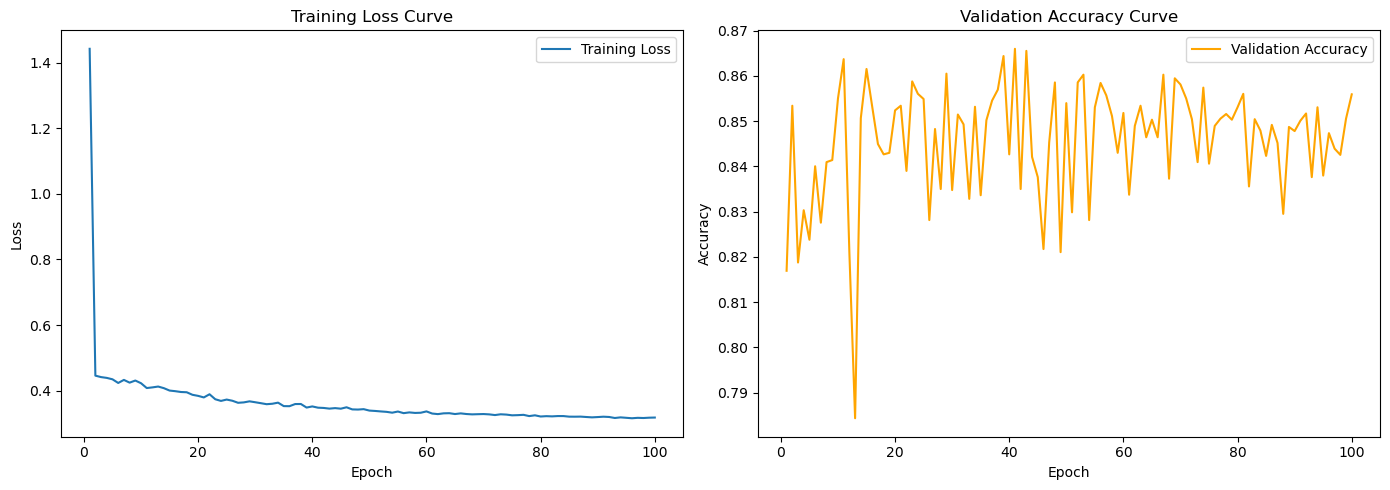

In [12]:
# Convert numpy arrays to torch tensors
X_train = torch.tensor(train_mfcc, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_val = torch.tensor(val_mfcc, dtype=torch.float32)
y_val = torch.tensor(val_labels, dtype=torch.long)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)

# Loss and optimizer
criterion = md.loss_Baseline(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 100
best_val_acc = 0.0
best_val_loss = float("inf")

# Tracking metrics
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
    
    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        torch.save(model.state_dict(), '_best_model.pth')
        print('... Model Saved')
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {avg_train_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

# Load best model
model.load_state_dict(torch.load('_best_model.pth'))

# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Curve')
ax1.legend()

ax2.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy Curve')
ax2.legend()

plt.tight_layout()
plt.show()

Evaluating the model.

Validation Accuracy: 0.8660
Validation F1 Score (weighted): 0.8512

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1572
           1       0.49      0.50      0.50       427
           2       0.15      0.03      0.04       341
           3       0.92      0.97      0.95      6406

    accuracy                           0.87      8746
   macro avg       0.58      0.56      0.56      8746
weighted avg       0.84      0.87      0.85      8746


Confusion Matrix:
[[1149  119   37  267]
 [ 143  213    7   64]
 [ 100   48    9  184]
 [ 144   52    7 6203]]





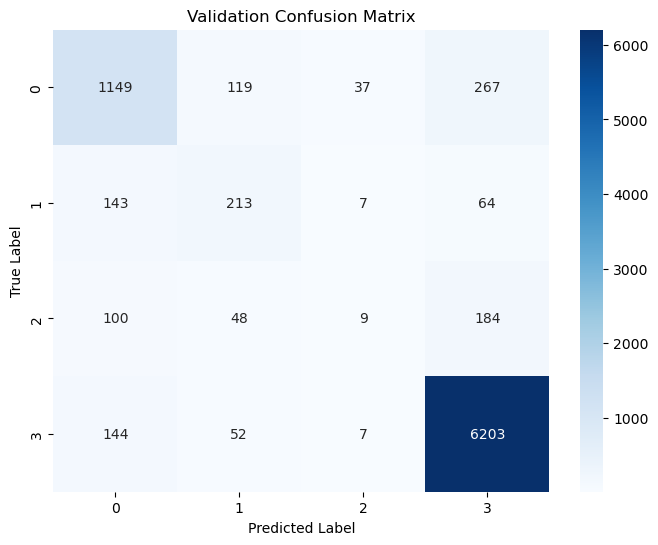

In [13]:
# Evaluate model on validation set
model.eval()
with torch.no_grad():
    val_preds = []
    val_true = []
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_true.extend(y_batch.cpu().numpy())

val_preds = np.array(val_preds)
val_true = np.array(val_true)

# Calculate metrics
accuracy = accuracy_score(val_true, val_preds)
f1 = f1_score(val_true, val_preds, average='weighted')
cm = confusion_matrix(val_true, val_preds)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation F1 Score (weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(val_true, val_preds))
print("\nConfusion Matrix:")
print(cm)
print("\n\n")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.show()